# Task 2 - Frozen Lake con Q-Learning (Gymnasium)

Implementacion del algoritmo Q-Learning para resolver el entorno FrozenLake-v1 usando la libreria Gymnasium.

## Task 2.1 - Instalacion y configuracion del entorno

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image
import io

Estados disponibles : 16
Acciones disponibles: 4
Acciones -> 0: izquierda, 1: abajo, 2: derecha, 3: arriba


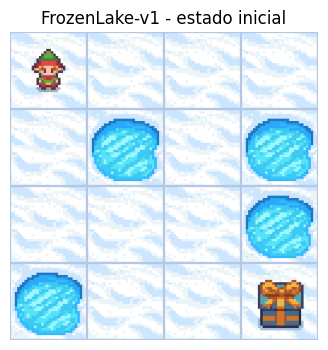

In [5]:
# inicializamos el entorno con hielo resbaloso y salida en rgb para poder renderizar
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")

n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"Estados disponibles : {n_states}")
print(f"Acciones disponibles: {n_actions}")
print("Acciones -> 0: izquierda, 1: abajo, 2: derecha, 3: arriba")

# mostramos el mapa inicial del entorno
frame = env.reset()[0]
env.render()
plt.figure(figsize=(4, 4))
plt.imshow(env.render())
plt.axis("off")
plt.title("FrozenLake-v1 - estado inicial")
plt.show()

## Task 2.2 - Implementacion de Q-Learning

### Inicializacion de la tabla Q

In [6]:
# tabla Q inicializada en ceros: filas = estados, columnas = acciones
Q = np.zeros((n_states, n_actions))

print(f"Forma de la tabla Q: {Q.shape}  (estados x acciones)")
print(Q)

Forma de la tabla Q: (16, 4)  (estados x acciones)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Hiperparametros

In [7]:
# hiperparametros del algoritmo
alpha   = 0.8     # learning rate: que tan rapido actualiza los valores Q
gamma   = 0.95    # factor de descuento: importancia de recompensas futuras
epsilon = 1.0     # probabilidad inicial de explorar (100%)
eps_min = 0.01    # epsilon minimo para no dejar de explorar del todo
eps_decay = 0.001 # cuanto reducimos epsilon por episodio
n_episodios = 10000

print("Hiperparametros definidos:")
print(f"  alpha     = {alpha}")
print(f"  gamma     = {gamma}")
print(f"  epsilon   = {epsilon}")
print(f"  eps_min   = {eps_min}")
print(f"  eps_decay = {eps_decay}")
print(f"  episodios = {n_episodios}")

Hiperparametros definidos:
  alpha     = 0.8
  gamma     = 0.95
  epsilon   = 1.0
  eps_min   = 0.01
  eps_decay = 0.001
  episodios = 10000


### Bucle de entrenamiento

Formula de actualizacion Q-Learning:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ R + \gamma \max_{a'} Q(s', a') - Q(s,a) \right]$$

Entrenamiento finalizado.
Epsilon final: 0.0100


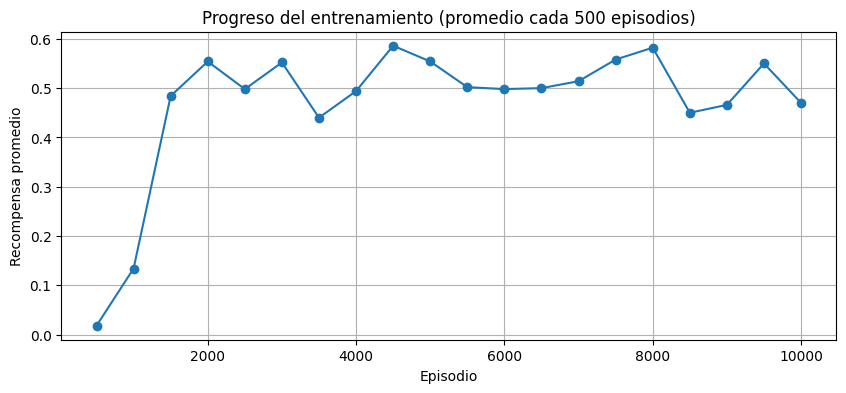

In [8]:
recompensas_por_episodio = []

# reiniciamos epsilon para el entrenamiento
epsilon = 1.0

for ep in range(n_episodios):
    estado, _ = env.reset()
    terminado = False
    recompensa_total = 0

    while not terminado:
        # politica epsilon-greedy: exploramos o explotamos segun epsilon
        if np.random.uniform(0, 1) < epsilon:
            accion = env.action_space.sample()  # exploracion aleatoria
        else:
            accion = np.argmax(Q[estado, :])    # explotacion de la tabla Q

        nuevo_estado, recompensa, terminado, truncado, _ = env.step(accion)

        # actualizamos Q con la formula de Q-Learning
        Q[estado, accion] = Q[estado, accion] + alpha * (
            recompensa + gamma * np.max(Q[nuevo_estado, :]) - Q[estado, accion]
        )

        estado = nuevo_estado
        recompensa_total += recompensa

        if truncado:
            break

    # decay de epsilon al final de cada episodio
    epsilon = max(eps_min, epsilon - eps_decay)
    recompensas_por_episodio.append(recompensa_total)

print("Entrenamiento finalizado.")
print(f"Epsilon final: {epsilon:.4f}")

# graficamos la recompensa promedio por bloque de 500 episodios
bloque = 500
promedios = [
    np.mean(recompensas_por_episodio[i:i+bloque])
    for i in range(0, n_episodios, bloque)
]

plt.figure(figsize=(10, 4))
plt.plot(range(bloque, n_episodios + 1, bloque), promedios, marker="o")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title("Progreso del entrenamiento (promedio cada 500 episodios)")
plt.grid(True)
plt.show()

In [9]:
# mostramos la tabla Q final para ver que valores aprendio el agente
print("Tabla Q entrenada:")
print(np.round(Q, 3))

Tabla Q entrenada:
[[0.426 0.051 0.265 0.048]
 [0.003 0.01  0.022 0.312]
 [0.136 0.004 0.007 0.004]
 [0.009 0.001 0.005 0.08 ]
 [0.574 0.064 0.077 0.029]
 [0.    0.    0.    0.   ]
 [0.002 0.    0.001 0.   ]
 [0.    0.    0.    0.   ]
 [0.045 0.043 0.008 0.642]
 [0.013 0.266 0.027 0.004]
 [0.04  0.002 0.001 0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.1   0.39  0.875 0.155]
 [0.224 0.981 0.302 0.245]
 [0.    0.    0.    0.   ]]


## Task 2.3 - Prueba del agente entrenado

Ejecutamos 10 episodios con epsilon = 0 (solo explotacion, sin exploracion).

In [10]:
n_test = 10
victorias = 0
nombres_acciones = {0: "izq", 1: "aba", 2: "der", 3: "arr"}

for ep in range(n_test):
    estado, _ = env.reset()
    terminado = False
    pasos = []

    while not terminado:
        # epsilon = 0: siempre tomamos la mejor accion conocida
        accion = np.argmax(Q[estado, :])
        pasos.append((estado, nombres_acciones[accion]))
        estado, recompensa, terminado, truncado, _ = env.step(accion)

        if truncado:
            break

    gano = recompensa == 1.0
    if gano:
        victorias += 1

    resultado = "GANO" if gano else "PERDIO"
    print(f"Episodio {ep+1:2d}: {resultado} | pasos: {len(pasos)} | trayectoria: {pasos}")

print(f"\nVictorias: {victorias}/{n_test}")

Episodio  1: GANO | pasos: 89 | trayectoria: [(0, 'izq'), (0, 'izq'), (0, 'izq'), (4, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (4, 'izq'), (8, 'arr'), (8, 'arr'), (4, 'izq'), (8, 'arr'), (4, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (4, 'izq'), (8, 'arr'), (8, 'arr'), (4, 'izq'), (8, 'arr'), (4, 'izq'), (8, 'arr'), (9, 'aba'), (13, 'der'), (9, 'aba'), (10, 'izq'), (6, 'izq'), (2, 'izq'), (2, 'izq'), (2, 'izq'), (1, 'arr'), (0, 'izq'), (4, 'izq'), (8, 'arr'), (8, 'arr'), (8, 'arr'), (8, 'arr'), (4, 'izq'), (4, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (4, 'izq'), (4, 'izq'), (0, 'izq'), (4, 'izq'), (4, 'izq'), (4, 'izq'), (0, 'izq'), (0, 'izq'), (4, 'izq'), (0, 'izq'), (4, 'izq'), (4, 'izq'), (8, 'arr'), (8, 'arr'), (4, 'izq'), (4, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (0, 'izq'), (4, 'izq'), (8, 

In [11]:
# calculamos y reportamos el win rate
win_rate = (victorias / n_test) * 100
print(f"Win Rate: {victorias}/{n_test} = {win_rate:.1f}%")

Win Rate: 7/10 = 70.0%


### Visualizacion de un episodio exitoso

Corremos el entorno hasta encontrar un episodio ganador y mostramos frame a frame.

In [12]:
frames_exitosos = []
intentos = 0
max_intentos = 200  # limite para no ciclar infinito

# buscamos un episodio donde el agente gane para visualizarlo
while intentos < max_intentos:
    estado, _ = env.reset()
    terminado = False
    frames = [env.render()]

    while not terminado:
        accion = np.argmax(Q[estado, :])
        estado, recompensa, terminado, truncado, _ = env.step(accion)
        frames.append(env.render())
        if truncado:
            break

    intentos += 1
    if recompensa == 1.0:
        frames_exitosos = frames
        print(f"Episodio exitoso encontrado en el intento {intentos} ({len(frames)} pasos)")
        break

if not frames_exitosos:
    print("No se encontro episodio exitoso en los intentos dados. Mostrando ultimo episodio.")
    frames_exitosos = frames

Episodio exitoso encontrado en el intento 3 (29 pasos)


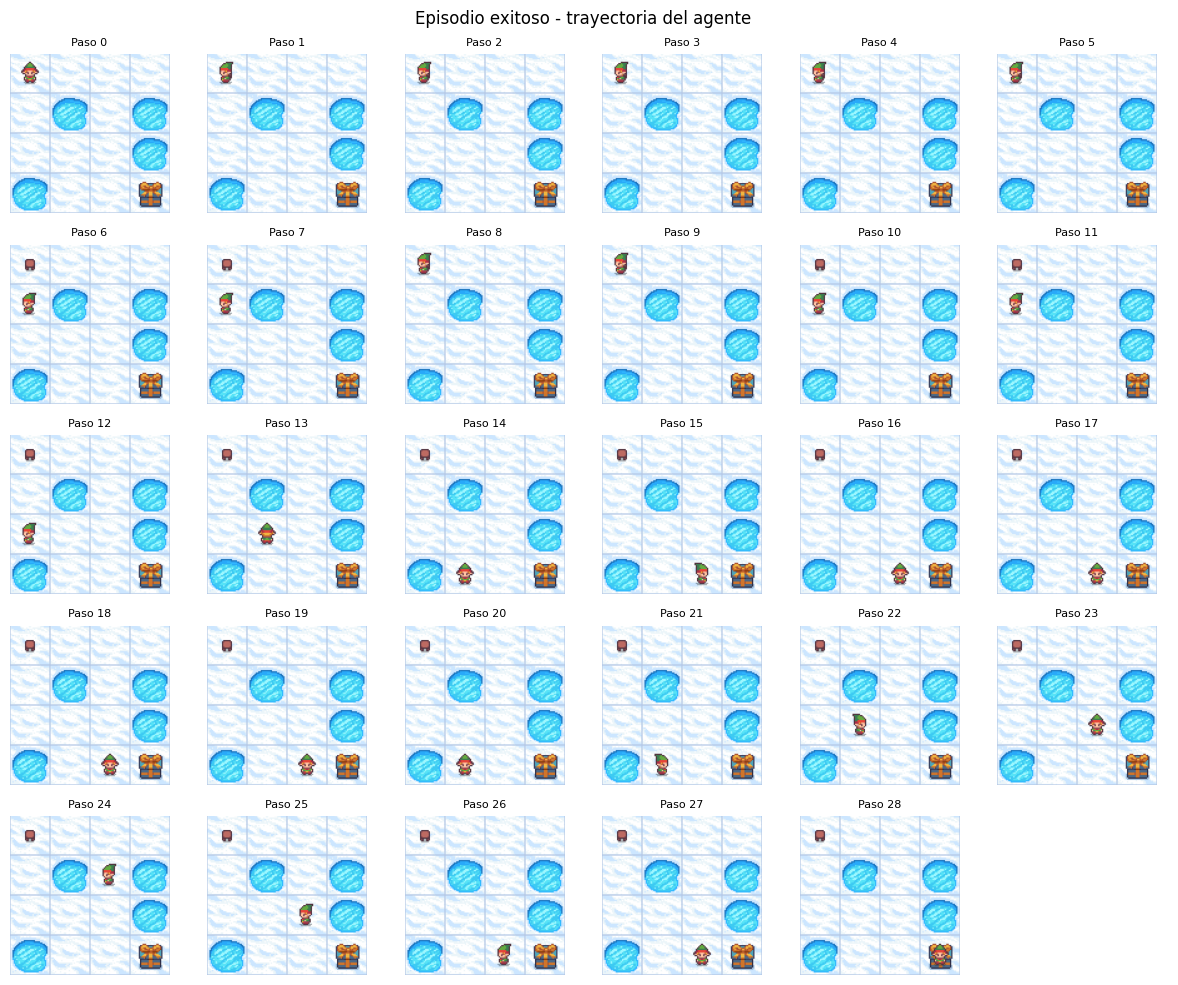

In [13]:
# mostramos cada frame del episodio exitoso en una grilla
n_frames = len(frames_exitosos)
cols = min(6, n_frames)
rows = (n_frames + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = np.array(axes).flatten()

for i, frame in enumerate(frames_exitosos):
    axes[i].imshow(frame)
    axes[i].set_title(f"Paso {i}", fontsize=8)
    axes[i].axis("off")

# ocultamos los ejes sobrantes si los hay
for j in range(n_frames, len(axes)):
    axes[j].axis("off")

plt.suptitle("Episodio exitoso - trayectoria del agente", fontsize=12)
plt.tight_layout()
plt.show()

env.close()